In [1]:
#  ------  Encodage -------- Normalisation ---------- --------Imputation ------------------- selection -----  extration 


#--- donnéé = valeur Num ----=> meme echelle -----  => Replace donné Manquante--------  ==> variale Utile  -----  nouvelle variale

#                 sklearn.processing                 sklearn.impute                sklearn.feature_selection       sklearn.feature_extraction

In [1]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
x = np.array(['chat',
              'chien',
              'chat',
              'Oiseau'])

In [3]:
transformer = LabelEncoder()
transformer.fit(x)

LabelEncoder()

In [4]:
transformer.transform(x) # methode 01

array([1, 2, 1, 0])

In [5]:
transformer.fit_transform(x)    # methode 02 de transformation   

array([1, 2, 1, 0])

In [6]:
#      TRANSFORMER D ENCODAGE

In [7]:
#  LABEL_ENCODER  , seulement sur une ligne

In [26]:
y = np.array(['chat','chien','chat','Oiseau'])

In [27]:
encoder = LabelEncoder()
encoder.fit(y)

LabelEncoder()

In [28]:
encoder.classes_

array(['Oiseau', 'chat', 'chien'], dtype='<U6')

In [30]:
encoder.fit_transform(y)

array([1, 2, 1, 0])

In [31]:
#  encodage   inverse

In [33]:
encoder.inverse_transform(np.array([0,0,1,2,2]))

array(['Oiseau', 'Oiseau', 'chat', 'chien', 'chien'], dtype='<U6')

In [40]:
from sklearn.preprocessing import OrdinalEncoder

In [41]:
x = np.array([['chat', 'Poils'],
              ['chien', 'Poils'],
              ['chat', 'Poils'],
              ['Oiseau', 'lumes']])

In [42]:
encoder = OrdinalEncoder()
encoder.fit_transform(x)

array([[1., 0.],
       [2., 0.],
       [1., 0.],
       [0., 1.]])

In [48]:
from sklearn.preprocessing import LabelBinarizer

In [49]:
y = np.array(['chat','chien','chat','Oiseau'])

In [50]:
encoder = LabelBinarizer()
encoder.fit_transform(y)

array([[0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0]])

In [51]:
encoder = LabelBinarizer(sparse_output=True)  # compression des données
encoder.fit_transform(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (4, 3)>

In [52]:
from sklearn.preprocessing import OneHotEncoder

In [53]:
x = np.array([['chat', 'Poils'],
              ['chien', 'Poils'],
              ['chat', 'Poils'],
              ['Oiseau', 'lumes']])

In [54]:
encoder = OneHotEncoder()
encoder.fit_transform(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (4, 5)>

In [55]:
#    00004    LA NORMALISATION

In [60]:
from sklearn.preprocessing import MinMaxScaler

In [58]:
x = np.array([[70],
             [80],
             [120]])

In [63]:
scaler= MinMaxScaler()
scaler.fit_transform(x)

array([[0. ],
       [0.2],
       [1. ]])

In [64]:
x_test = np.array([[90]])
scaler.transform(x_test)

array([[0.4]])

In [65]:
from sklearn.datasets import load_iris

(150, 4)


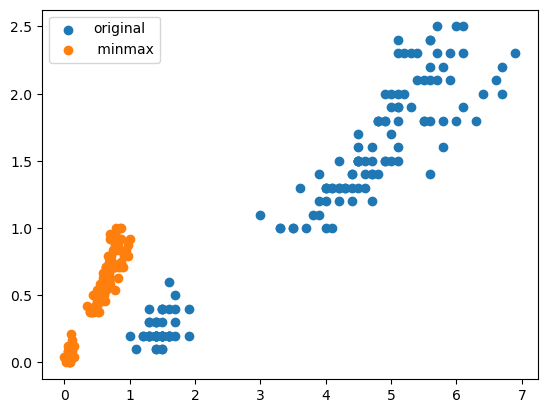

In [69]:
iris = load_iris()

x = iris.data
y = iris.target

x_minmax= MinMaxScaler().fit_transform(x)

print(x.shape)
plt.scatter(x[:, 2], x[:, 3], label='original')
plt.scatter(x_minmax[:,2],x_minmax[:, 3], label=' minmax')
plt.legend()
plt.show()

In [ ]:
#       standarisation 

In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
x = np.array([[70],
             [80],
             [120]])

In [72]:
scaler= StandardScaler()
scaler.fit_transform(x)

array([[-0.9258201 ],
       [-0.46291005],
       [ 1.38873015]])

(150, 4)


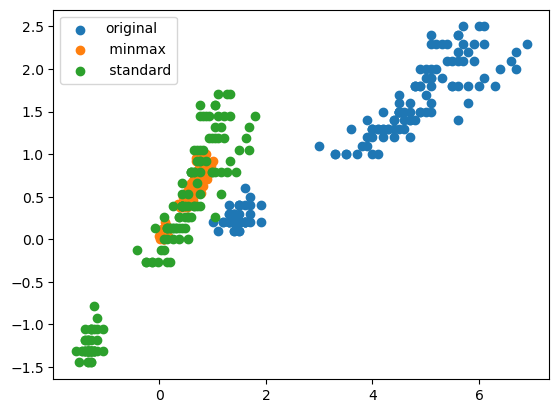

In [74]:
iris = load_iris()

x = iris.data
y = iris.target

x_minmax= MinMaxScaler().fit_transform(x)
x_stand = StandardScaler().fit_transform(x)
print(x.shape)
plt.scatter(x[:, 2], x[:, 3], label='original')
plt.scatter(x_minmax[:,2],x_minmax[:, 3], label=' minmax')
plt.scatter(x_stand[:,2],x_stand[:, 3], label=' standard')
plt.legend()
plt.show()

In [78]:
#   sensible aux OUTLIERS

In [79]:
from sklearn.preprocessing import RobustScaler

(160, 4)


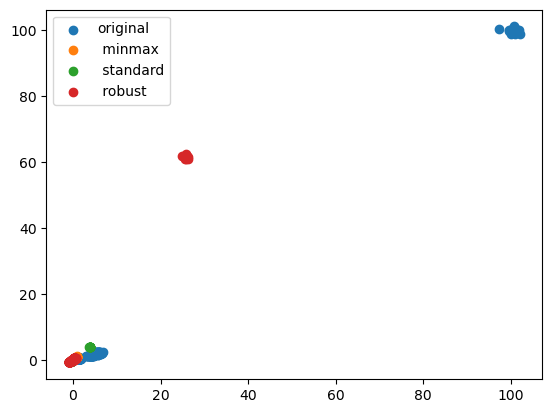

In [82]:
iris = load_iris()

x = iris.data
y = iris.target


outliers = np.full((10, 4), 100)  + np.random.randn(10,4)
x = np.vstack((x, outliers))

x_minmax= MinMaxScaler().fit_transform(x)
x_stand = StandardScaler().fit_transform(x)
x_robust = RobustScaler().fit_transform(x)

print(x.shape)
plt.scatter(x[:, 2], x[:, 3], label='original')
plt.scatter(x_minmax[:,2],x_minmax[:, 3], label=' minmax')
plt.scatter(x_stand[:,2],x_stand[:, 3], label=' standard')
plt.scatter(x_robust[:,2],x_robust[:, 3], label=' robust')
plt.legend()
plt.show()

In [83]:
#     autre transformer

In [84]:
#    POLYNOMIAL  FEATURES

In [85]:
from sklearn.preprocessing import PolynomialFeatures

In [86]:
x = np.array([[1],
              [2],
              [0.5]])

In [87]:
PolynomialFeatures(3).fit_transform(x)

array([[1.   , 1.   , 1.   , 1.   ],
       [1.   , 2.   , 4.   , 8.   ],
       [1.   , 0.5  , 0.25 , 0.125]])

In [89]:
from sklearn.linear_model import LinearRegression

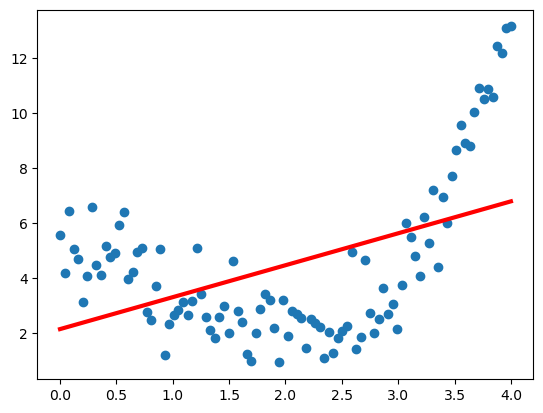

In [90]:
x = np.linspace(0, 4, 100).reshape((100, 1))
y = x**2 + 5*np.cos(x) + np.random.randn(100, 1)

plt.scatter(x,y)

model = LinearRegression().fit(x, y)
y_pred = model.predict(x)

plt.plot(x, y_pred, c='r', lw =3)

In [ ]:
# avec une fontion polynomiale

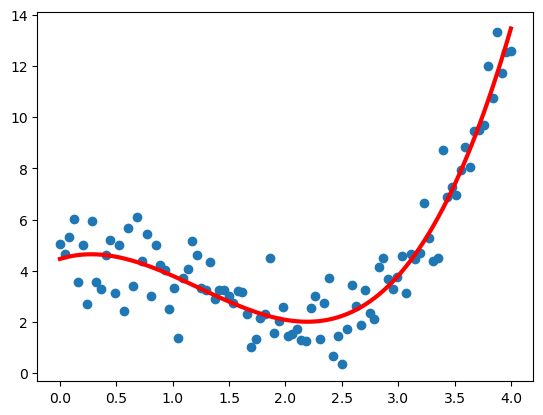

In [91]:
x = np.linspace(0, 4, 100).reshape((100, 1))
y = x**2 + 5*np.cos(x) + np.random.randn(100, 1)

x_poly = PolynomialFeatures(3).fit_transform(x)

plt.scatter(x,y)

model = LinearRegression().fit(x_poly, y)
y_pred = model.predict(x_poly)

plt.plot(x, y_pred, c='r', lw =3)

In [ ]:
# transformation  non LIneaire

In [92]:
from sklearn.preprocessing import PowerTransformer

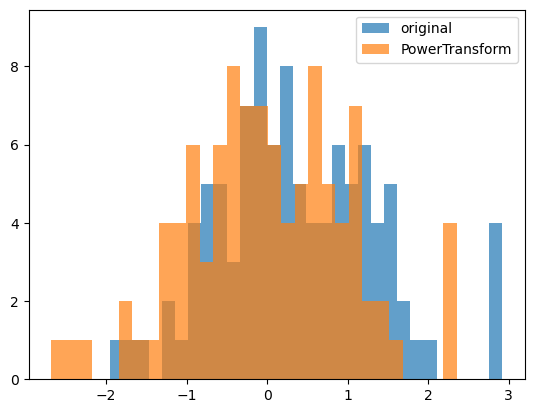

In [93]:
np.random.seed(0)

x = np.random.rand(100, 2) + np.random.randn(100, 2)

x_2 = PowerTransformer().fit_transform(x)

plt.hist(x[:,0], bins=30, alpha=0.7, label='original')
plt.hist(x_2[:, 0], bins=30, alpha=0.7, label='PowerTransform')
plt.legend()
plt.show()


In [ ]:
#                        APPLICATION 

In [48]:
import numpy as np
import matplotlib.pyplot as plt


In [49]:
from sklearn.datasets import load_iris

In [50]:
iris = load_iris()

x = iris.data
y = iris.target



In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 5)     #diviser les données en des tableaux  avec 20% des données dans le test

In [66]:
# Transformer

scaler = StandardScaler()
x_train_transformed = scaler.fit_transform(x_train)

#Estimator

model = SGDClassifier(random_state=0)
model.fit(x_train_transformed, y_train)


#test

x_test_transformed = scaler.transform(x_test)
model.predict(x_test_transformed)

array([1, 1, 2, 0, 2, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0, 1, 2,
       0, 1, 1, 2, 1, 1, 1, 2])

In [92]:
model.score(x_test, y_test)

0.9

In [67]:
#        PIPeLINE

In [85]:
from sklearn.pipeline import make_pipeline

In [86]:
model = make_pipeline(StandardScaler(),
                      SGDClassifier())

model.fit(x_train, y_train)
model.predict(x_test)

array([1, 1, 2, 0, 2, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0, 1, 2,
       0, 1, 1, 2, 1, 1, 1, 2])

In [87]:
#               DÉMONSTRATION 

In [88]:
from sklearn.model_selection import GridSearchCV

In [89]:
param_grid = {
    'polynomialfeatures_degree': [2, 3, 4],
    'sgdclassifier_penalty' : ['11', '12']}

In [90]:
from sklearn.model_selection import GridSearchCV

In [91]:
grid = GridSearchCV(make_pipeline( PolynomialFeatures(),
                      StandardScaler(),
                      SGDClassifier(random_state=0)), param_grid, cv=4)

grid.fit(x_train, y_train)

grid.score(x_test, y_test)

ValueError: Invalid parameter 'polynomialfeatures_degree' for estimator Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(random_state=0))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].